In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Code for Removing the Background
import os
import cv2
import numpy as np

(Error)def segment_plant(image_path):#remove (Error to run the code)
    """Segments the banana plant and blacks out the background."""
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Define green color range for segmentation
    lower_green = np.array([30, 40, 40])
    upper_green = np.array([90, 255, 255])

    # Create mask
    mask = cv2.inRange(hsv, lower_green, upper_green)

    # Refine mask
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=3)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)

    # Create output image with black background
    result = np.zeros_like(image_rgb)
    result[mask > 0] = image_rgb[mask > 0]

    return result

# Define the input and output folder paths
input_folders = ["/content/drive/MyDrive/Test/healthy",
                 "/content/drive/MyDrive/Train/healthy",
                 "/content/drive/MyDrive/Validation/healthy"]  # Change to your actual dataset path
output_folders = ["/content/drive/MyDrive/01/Test",
                  "/content/drive/MyDrive/01/Train",
                  "/content/drive/MyDrive/01/Validation"]  # Change to desired output folder

# Process images in each folder
for input_folder, output_folder in zip(input_folders, output_folders):
    os.makedirs(output_folder, exist_ok=True)

    for filename in os.listdir(input_folder):
        if filename.lower().endswith(('png', 'jpg', 'jpeg')):
            input_path = os.path.join(input_folder, filename)
            output_path = os.path.join(output_folder, filename)

            # Segment the plant and save the result
            segmented_image = segment_plant(input_path)
            cv2.imwrite(output_path, cv2.cvtColor(segmented_image, cv2.COLOR_RGB2BGR))

print("Segmentation complete. Processed images are saved in the corresponding output folders.")


Segmentation complete. Processed images are saved in the corresponding output folders.


<ipython-input-6-175697764e9e>:21: UserWarning: Argument(s) 'pad_value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=IMG_SIZE[0], min_width=IMG_SIZE[1], border_mode=cv2.BORDER_CONSTANT, pad_value=(0, 0, 0)),


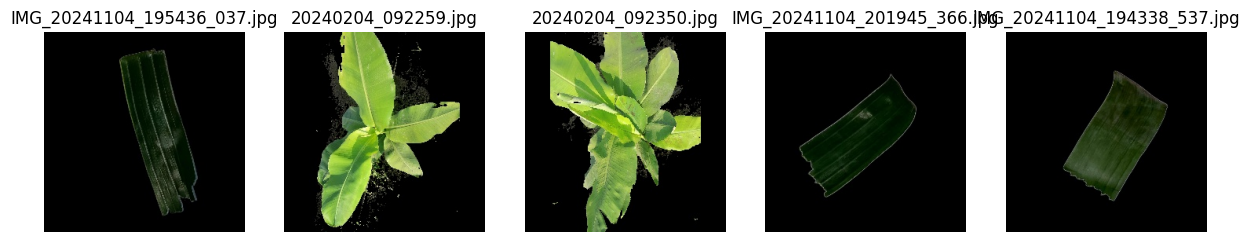

In [ ]:
# Code

import cv2
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import albumentations as A

# Define input and output paths
(Error)INPUT_DIRS = ["/content/drive/MyDrive/Validation/healthy"]   #Remove (Error) to run the code
OUTPUT_DIR = "/content/drive/MyDrive/01/Validation"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Standardized image size (change as needed)
IMG_SIZE = (256, 256)

# Augmentation pipeline without color effects
transform = A.Compose([
    A.LongestMaxSize(max_size=max(IMG_SIZE)),  # Resize while maintaining aspect ratio
    A.PadIfNeeded(min_height=IMG_SIZE[0], min_width=IMG_SIZE[1], border_mode=cv2.BORDER_CONSTANT, pad_value=(0, 0, 0)),
])

# Load and process images
def load_and_resize_images(input_dirs, output_dir, num_samples=5):
    all_images = []

    for input_dir in input_dirs:
        if not os.path.isdir(input_dir):
            print(f"Warning: {input_dir} is not a valid directory.")
            continue

        images = [os.path.join(input_dir, f) for f in os.listdir(input_dir) if f.lower().endswith(('png', 'jpg', 'jpeg'))]
        all_images.extend(images)

    if not all_images:
        raise ValueError("No images found in the specified directories.")

    for img_path in all_images:
        img_name = os.path.basename(img_path)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        resized = transform(image=img)['image']

        # Convert back to numpy
        resized_np = np.array(resized)

        # Save resized image
        output_path = os.path.join(output_dir, img_name)
        cv2.imwrite(output_path, cv2.cvtColor(resized_np, cv2.COLOR_RGB2BGR))

    # Display some images
    sample_images = random.sample(os.listdir(output_dir), min(num_samples, len(all_images)))
    fig, axes = plt.subplots(1, len(sample_images), figsize=(15, 5))
    for ax, img_name in zip(axes, sample_images):
        img = cv2.imread(os.path.join(output_dir, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(img_name)
    plt.show()

# Run the function
load_and_resize_images(INPUT_DIRS, OUTPUT_DIR)